# Practical 3: Regression Trees



# A. Basketball Player Salary Prediction

- Perform Decision Tree regression on predicting basketball player salary.
- Analyze the model performance.
- Check effect of tree pruning on model performance.

In [ ]:
# Importing the required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn imports
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.impute import KNNImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Other imports
import joblib

In [ ]:
# Load the dataset
df = pd.read_csv("Player (1).csv")

# Display the first few rows
df.head()

,Unnamed: 0,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,...,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
0,-Andy Allanson,293,66,1,30,29,14,1,293,66,...,30,29,14,A,E,446,33,20,NaN,A
1,-Alan Ashby,315,81,7,24,38,39,14,3449,835,...,321,414,375,N,W,632,43,10,475.0,N
2,-Alvin Davis,479,130,18,66,72,76,3,1624,457,...,224,266,263,A,W,880,82,14,480.0,A
3,-Andre Dawson,496,141,20,65,78,37,11,5628,1575,...,828,838,354,N,E,200,11,3,500.0,N
4,-Andres Galarraga,321,87,10,39,42,30,2,396,101,...,48,46,33,N,E,805,40,4,91.5,N


In [ ]:
# Check the shape of the dataframe
df.shape

(322, 21)

In [ ]:
# Get basic information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 322 entries, 0 to 321
Data columns (total 21 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  322 non-null    object 
 1   AtBat       322 non-null    int64  
 2   Hits        322 non-null    int64  
 3   HmRun       322 non-null    int64  
 4   Runs        322 non-null    int64  
 5   RBI         322 non-null    int64  
 6   Walks       322 non-null    int64  
 7   Years       322 non-null    int64  
 8   CAtBat      322 non-null    int64  
 9   CHits       322 non-null    int64  
 10  CHmRun      322 non-null    int64  
 11  CRuns       322 non-null    int64  
 12  CRBI        322 non-null    int64  
 13  CWalks      322 non-null    int64  
 14  League      322 non-null    object 
 15  Division    322 non-null    object 
 16  PutOuts     322 non-null    int64  
 17  Assists     322 non-null    int64  
 18  Errors      322 non-null    int64  
 19  Salary      263 non-null    f

In [ ]:
# Statistical summary of numerical columns
df.describe()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors,Salary
count,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,322.00000,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,263.000000
mean,380.928571,101.024845,10.770186,50.909938,48.027950,38.742236,7.444099,2648.68323,717.571429,69.490683,358.795031,330.118012,260.239130,288.937888,106.913043,8.040373,535.925882
std,153.404981,46.454741,8.709037,26.024095,26.166895,21.639327,4.926087,2324.20587,654.472627,86.266061,334.105886,333.219617,267.058085,280.704614,136.854876,6.368359,451.118681
min,16.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,19.00000,4.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,67.500000
25%,255.250000,64.000000,4.000000,30.250000,28.000000,22.000000,4.000000,816.75000,209.000000,14.000000,100.250000,88.750000,67.250000,109.250000,7.000000,3.000000,190.000000
50%,379.500000,96.000000,8.000000,48.000000,44.000000,35.000000,6.000000,1928.00000,508.000000,37.500000,247.000000,220.500000,170.500000,212.000000,39.500000,6.000000,425.000000
75%,512.000000,137.000000,16.000000,69.000000,64.750000,53.000000,11.000000,3924.25000,1059.250000,90.000000,526.250000,426.250000,339.250000,325.000000,166.000000,11.000000,750.000000
max,687.000000,238.000000,40.000000,130.000000,121.000000,105.000000,24.000000,14053.00000,4256.000000,548.000000,2165.000000,1659.000000,1566.000000,1378.000000,492.000000,32.000000,2460.000000


In [ ]:
# Summary of categorical columns
df.describe(include="object")

,Unnamed: 0,League,Division,NewLeague
count,322,322,322,322
unique,322,2,2,2
top,-Andy Allanson,A,W,A
freq,1,175,165,176


In [ ]:
# Check for missing values
df.isnull().sum()

Unnamed: 0     0
AtBat          0
Hits           0
HmRun          0
Runs           0
RBI            0
Walks          0
Years          0
CAtBat         0
CHits          0
CHmRun         0
CRuns          0
CRBI           0
CWalks         0
League         0
Division       0
PutOuts        0
Assists        0
Errors         0
Salary        59
NewLeague      0
dtype: int64

There are 59 null values in the salary column.

## Exploratory Data Analysis (EDA)

In [ ]:
# Separate numerical and categorical columns
numerical_cols = df.select_dtypes(exclude="object").columns
categorical_cols = df.select_dtypes(include="object").columns

print("Numerical columns:", numerical_cols)
print("Categorical columns:", categorical_cols)

Numerical columns: Index(['AtBat', 'Hits', 'HmRun', 'Runs', 'RBI', 'Walks', 'Years', 'CAtBat',
       'CHits', 'CHmRun', 'CRuns', 'CRBI', 'CWalks', 'PutOuts', 'Assists',
       'Errors', 'Salary'],
      dtype='object')
Categorical columns: Index(['Unnamed: 0', 'League', 'Division', 'NewLeague'], dtype='object')


### Numerical Feature Analysis

In [ ]:
# Set up subplot dimensions
num_cols = 4
num_rows = int(np.ceil(len(numerical_cols) / num_cols))

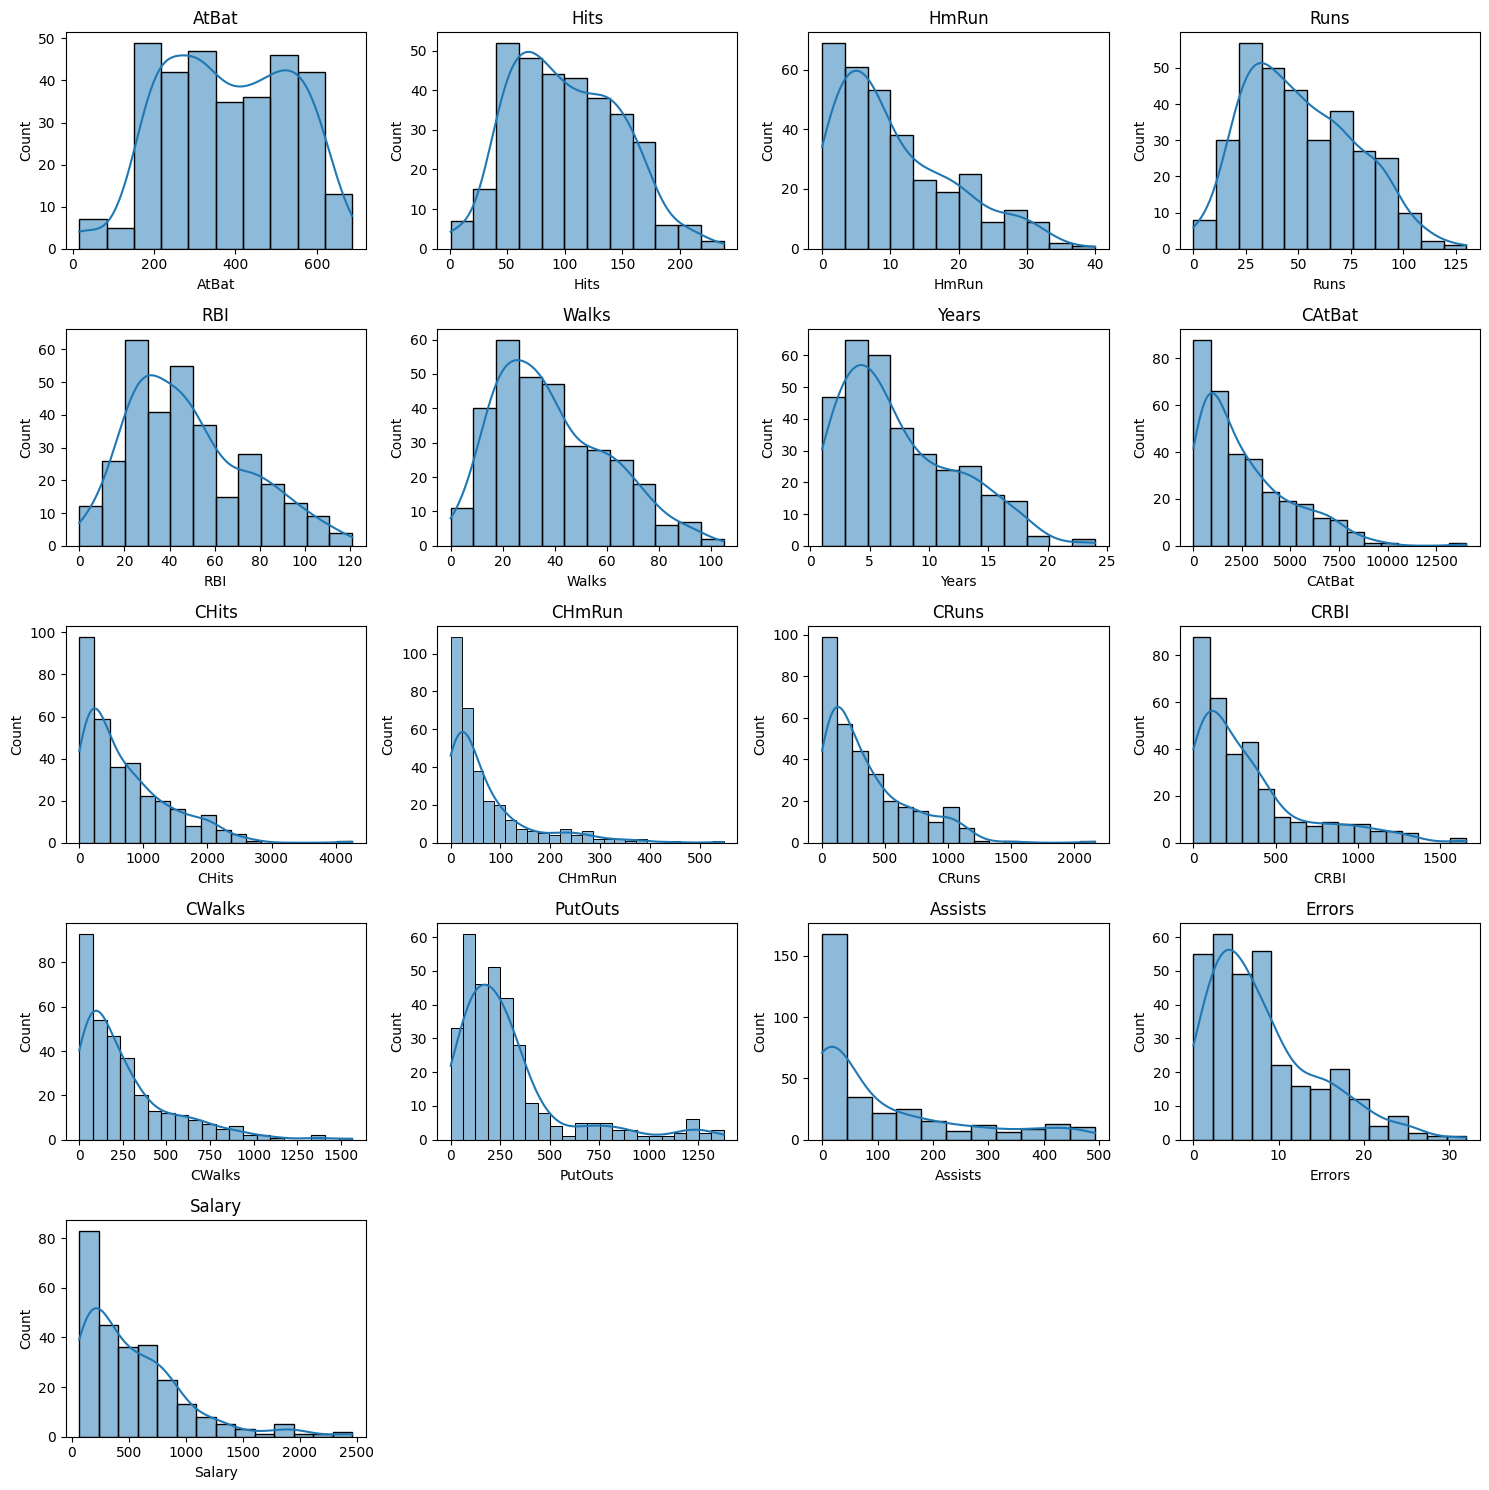

In [ ]:
# Plot distributions of numerical features
plt.figure(figsize=(15, 15))

for i, col in enumerate(numerical_cols):
    plt.subplot(num_rows, num_cols, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

More than half of the features are right-skewed.

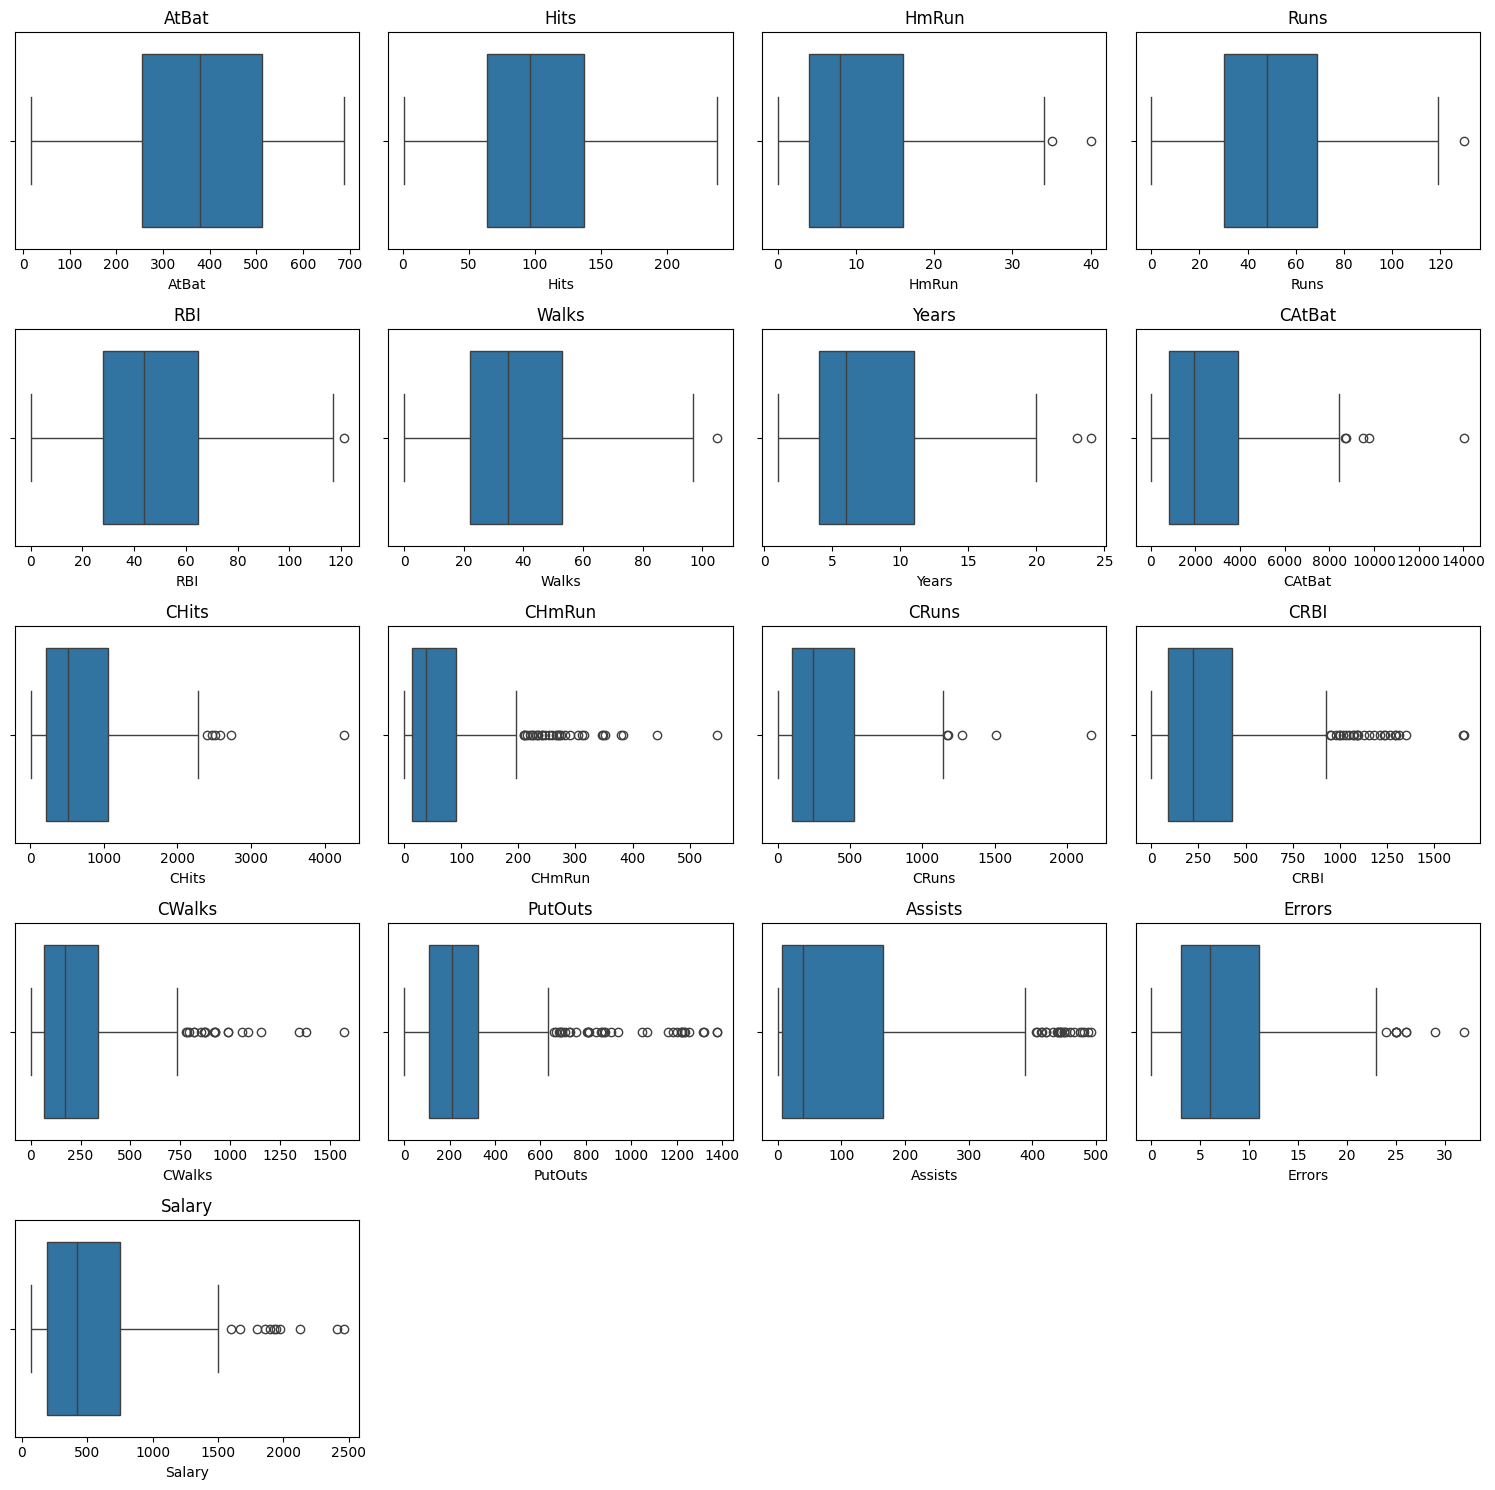

In [ ]:
# Plot boxplots for numerical features
plt.figure(figsize=(15, 15))

for i, col in enumerate(numerical_cols):
    plt.subplot(num_rows, num_cols, i + 1)
    sns.boxplot(x=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

Most numerical features have outliers, with some having many outliers.

In [ ]:
# Calculate correlation matrix for numerical features
num_corr = df[numerical_cols].corr()

num_corr

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors,Salary
AtBat,1.000000,0.967939,0.592198,0.913060,0.820539,0.669845,0.047372,0.235526,0.252717,0.236659,0.266534,0.244053,0.166123,0.317550,0.353824,0.352117,0.394771
Hits,0.967939,1.000000,0.562158,0.922187,0.811073,0.641211,0.044767,0.227565,0.255815,0.202712,0.261787,0.232005,0.151818,0.310673,0.320455,0.310038,0.438675
HmRun,0.592198,0.562158,1.000000,0.650988,0.855122,0.481014,0.116318,0.221882,0.220627,0.493227,0.262361,0.351979,0.233154,0.282923,-0.106329,0.039318,0.343028
Runs,0.913060,0.922187,0.650988,1.000000,0.798206,0.732213,0.004541,0.186497,0.204830,0.227913,0.250556,0.205976,0.182168,0.279347,0.220567,0.240475,0.419859
RBI,0.820539,0.811073,0.855122,0.798206,1.000000,0.615997,0.146168,0.294688,0.308201,0.441771,0.323285,0.393184,0.250914,0.343186,0.106591,0.193370,0.449457
Walks,0.669845,0.641211,0.481014,0.732213,0.615997,1.000000,0.136475,0.277175,0.280671,0.332473,0.338478,0.308631,0.424507,0.299515,0.149656,0.129382,0.443867
Years,0.047372,0.044767,0.116318,0.004541,0.146168,0.136475,1.000000,0.920289,0.903631,0.726872,0.882877,0.868812,0.838533,-0.004684,-0.080638,-0.162140,0.400657
CAtBat,0.235526,0.227565,0.221882,0.186497,0.294688,0.277175,0.920289,1.000000,0.995063,0.798836,0.983345,0.949219,0.906501,0.062283,0.002038,-0.066922,0.526135
CHits,0.252717,0.255815,0.220627,0.204830,0.308201,0.280671,0.903631,0.995063,1.000000,0.783306,0.984609,0.945141,0.890954,0.076547,-0.002523,-0.062756,0.548910
CHmRun,0.236659,0.202712,0.493227,0.227913,0.441771,0.332473,0.726872,0.798836,0.783306,1.000000,0.820243,0.929484,0.799983,0.112724,-0.158511,-0.138115,0.524931


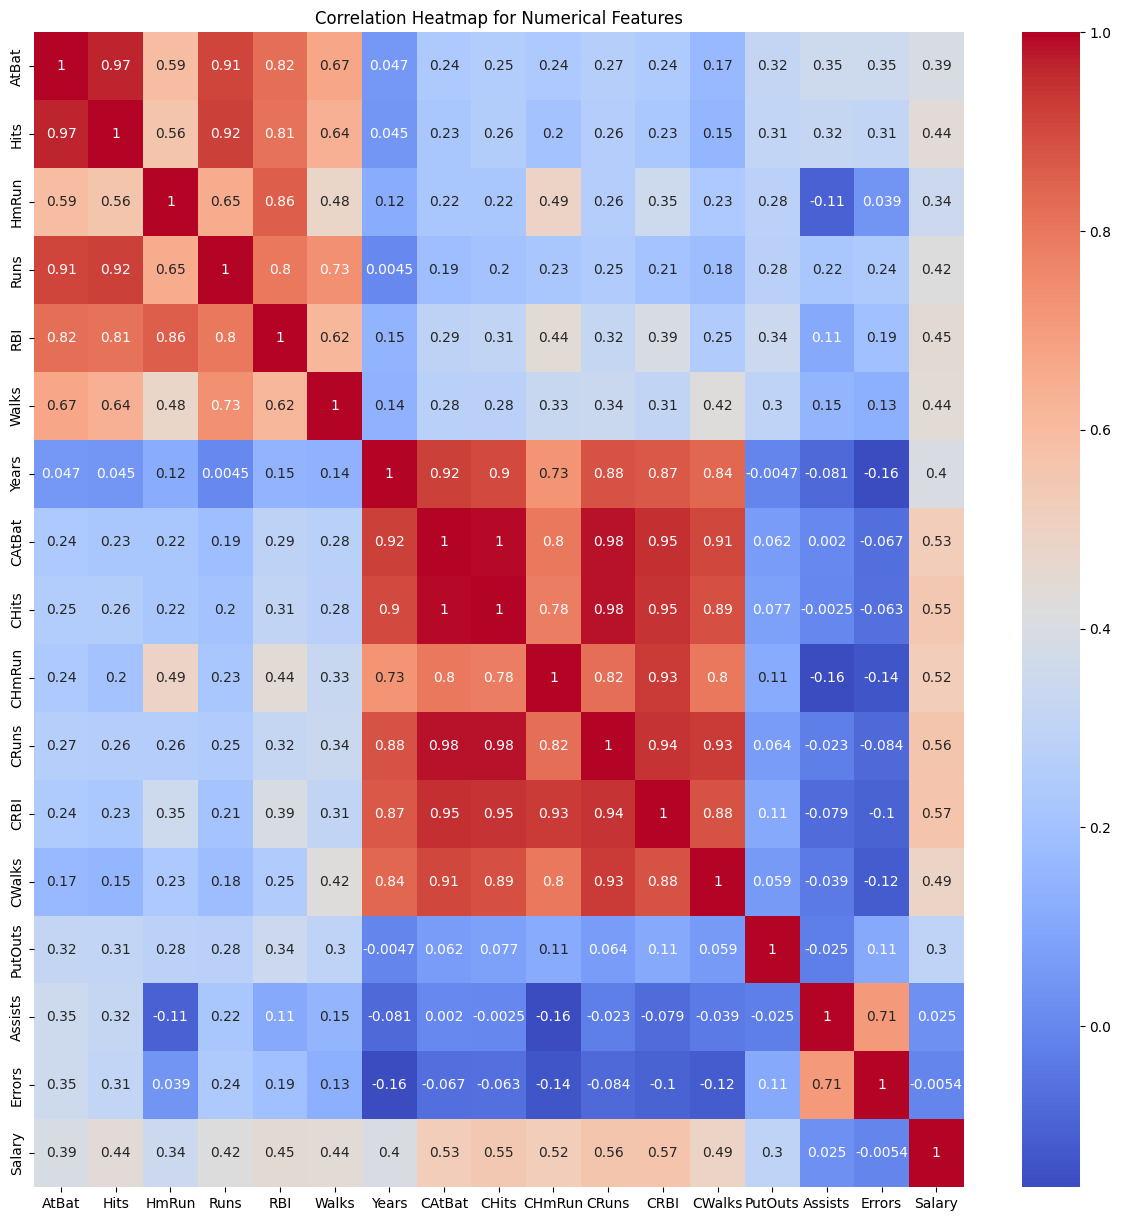

In [ ]:
# Visualize correlation heatmap
plt.figure(figsize=(15, 15))
sns.heatmap(num_corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap for Numerical Features")
plt.show()

### Categorical Feature Analysis

In [ ]:
# Set up subplot dimensions for categorical plots
num_cols = 3
num_rows = int(np.ceil(len(categorical_cols[1:]) / num_cols))  # Exclude 'Unnamed: 0'

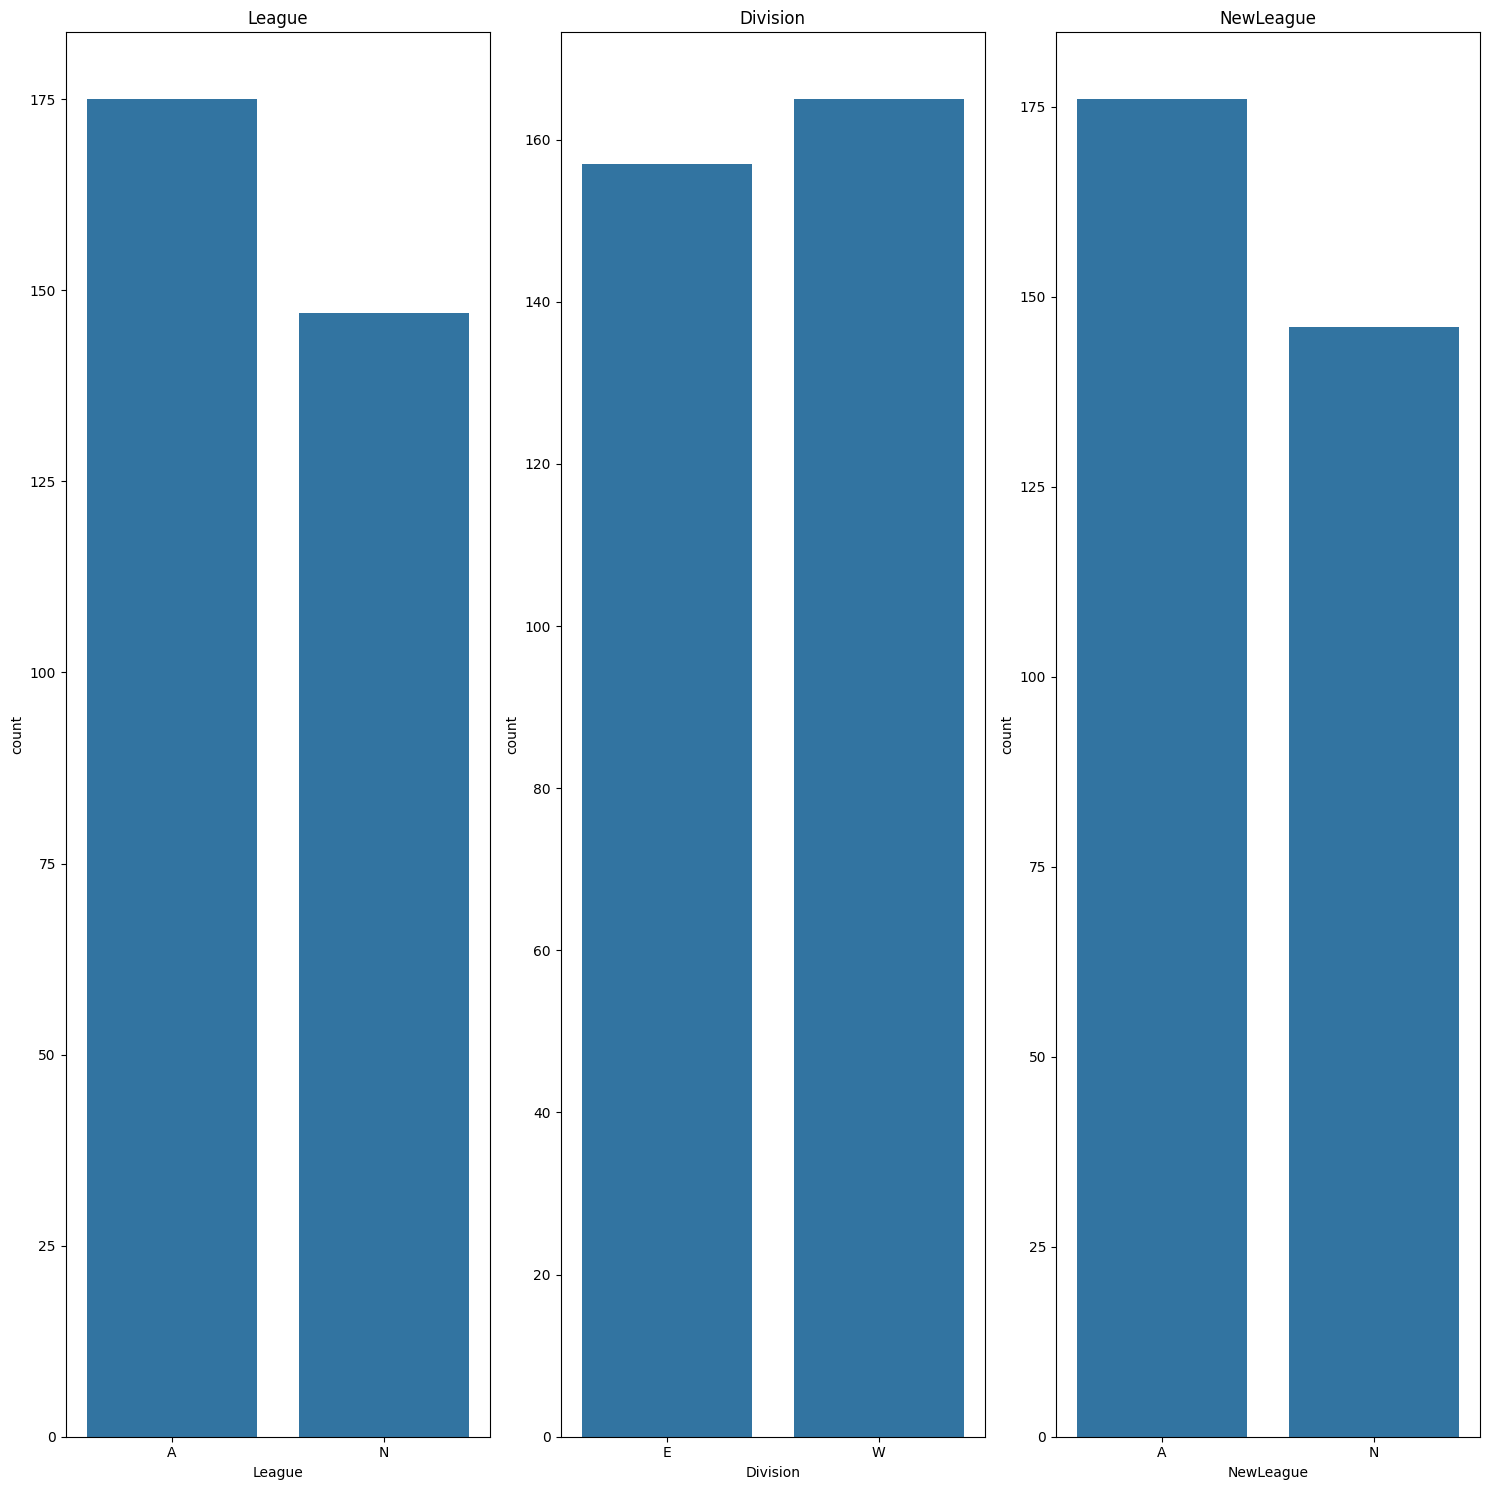

In [ ]:
# Plot count plots for categorical features
plt.figure(figsize=(15, 15))

for i, col in enumerate(categorical_cols[1:]):  # Skip 'Unnamed: 0'
    plt.subplot(num_rows, num_cols, i + 1)
    sns.countplot(x=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

The categorical columns show slight imbalance.

In [ ]:
# Encode categorical features for correlation analysis
df_copy = df.copy()
df_copy = df_copy.drop(columns=['Unnamed: 0'], axis=1)

# Use LabelEncoder for categorical columns
for col in categorical_cols[1:]:
    le = LabelEncoder()
    df_copy[col] = le.fit_transform(df_copy[col])
    print(f"{col} encoded successfully.")

League encoded successfully.
Division encoded successfully.
NewLeague encoded successfully.


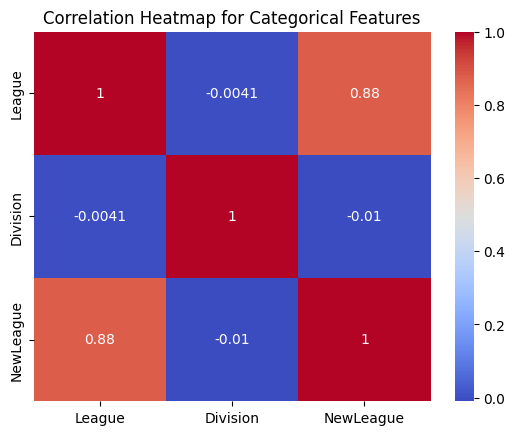

In [ ]:
# Calculate and visualize correlation for categorical features
cat_corr = df_copy[categorical_cols[1:]].corr()

sns.heatmap(cat_corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap for Categorical Features")
plt.show()

### Overall Correlation Analysis

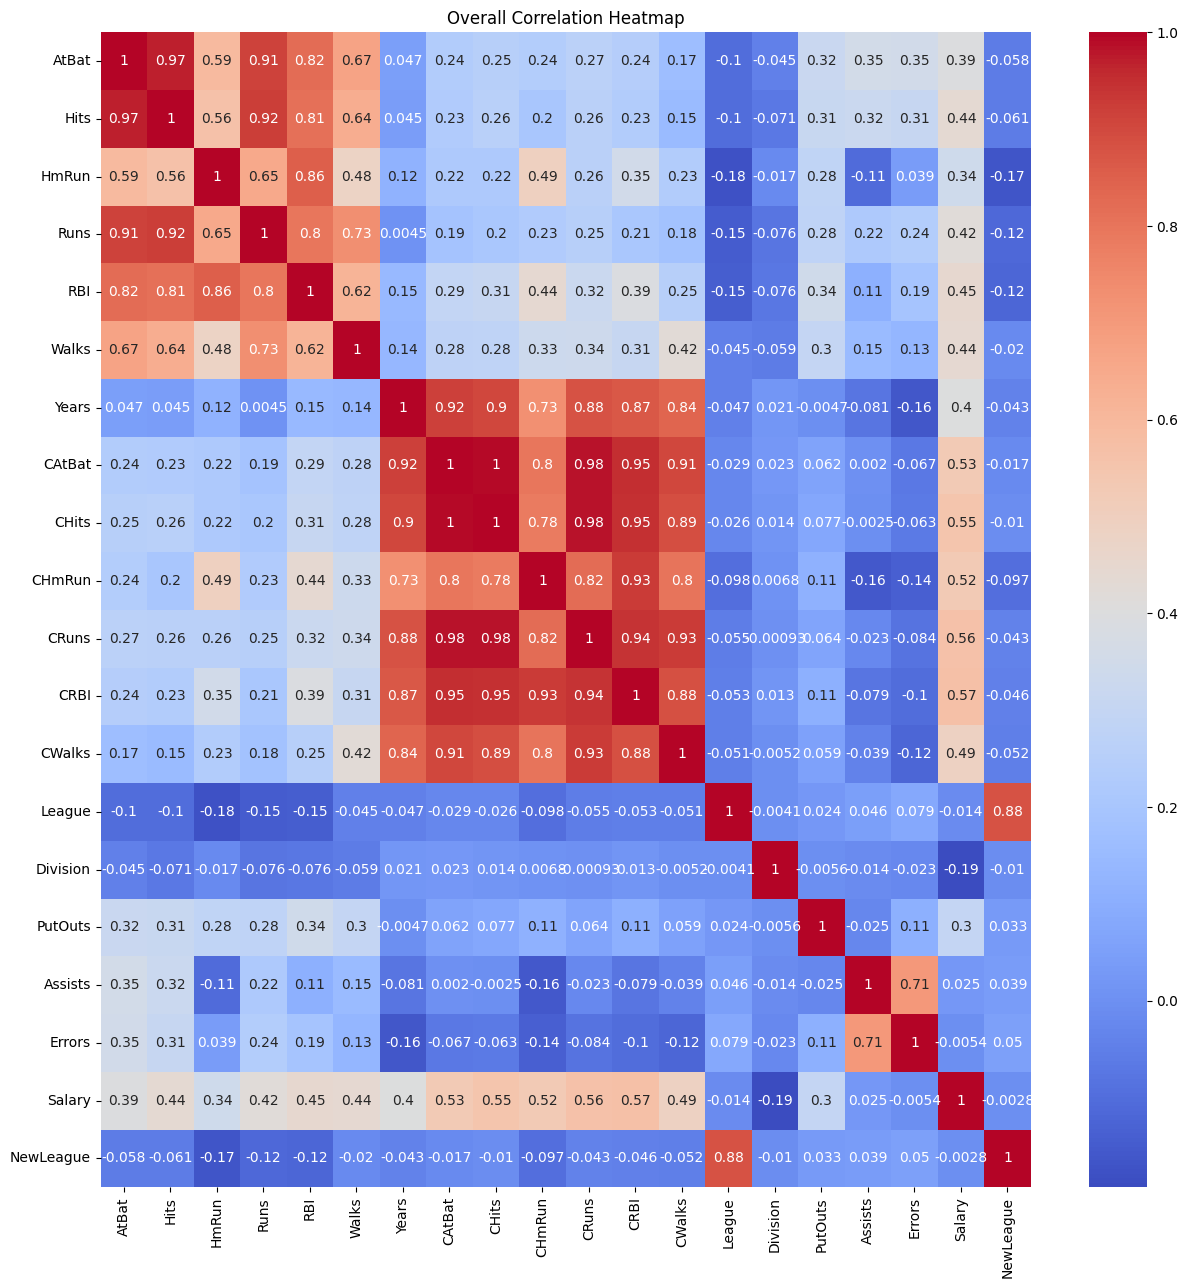

In [ ]:
# Compute overall correlation matrix
corr = df_copy.corr()

plt.figure(figsize=(15, 15))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Overall Correlation Heatmap")
plt.show()

In [ ]:
# Correlation with target variable (Salary)
corr_with_label = corr["Salary"]

corr_with_label.sort_values(ascending=False)

Salary       1.000000
CRBI         0.566966
CRuns        0.562678
CHits        0.548910
CAtBat       0.526135
CHmRun       0.524931
CWalks       0.489822
RBI          0.449457
Walks        0.443867
Hits         0.438675
Runs         0.419859
Years        0.400657
AtBat        0.394771
HmRun        0.343028
PutOuts      0.300480
Assists      0.025436
NewLeague   -0.002834
Errors      -0.005401
League      -0.014282
Division    -0.192514
Name: Salary, dtype: float64

Features like Assists, NewLeague, Errors, and League have very low correlation with Salary and may be insignificant.

## Feature Engineering and Preprocessing

### Feature Selection

In [ ]:
# Drop insignificant columns based on correlation analysis
columns_to_drop = ["Assists", "NewLeague", "Errors", "League", "Unnamed: 0"]

df = df.drop(columns=columns_to_drop)

In [ ]:
# Update numerical and categorical columns after dropping
numerical_cols = df.select_dtypes(exclude="object").columns
categorical_cols = df.select_dtypes(include="object").columns

### Handling Missing Values

In [ ]:
# Impute missing values in Salary using KNN Imputer
imputer = KNNImputer(n_neighbors=5)
df["Salary"] = imputer.fit_transform(df[["Salary"]])

### Handling Skewness with Transformations

In [ ]:
# Apply log transformation to reduce right skewness
for col in numerical_cols:
    df[col] = np.log1p(df[col])

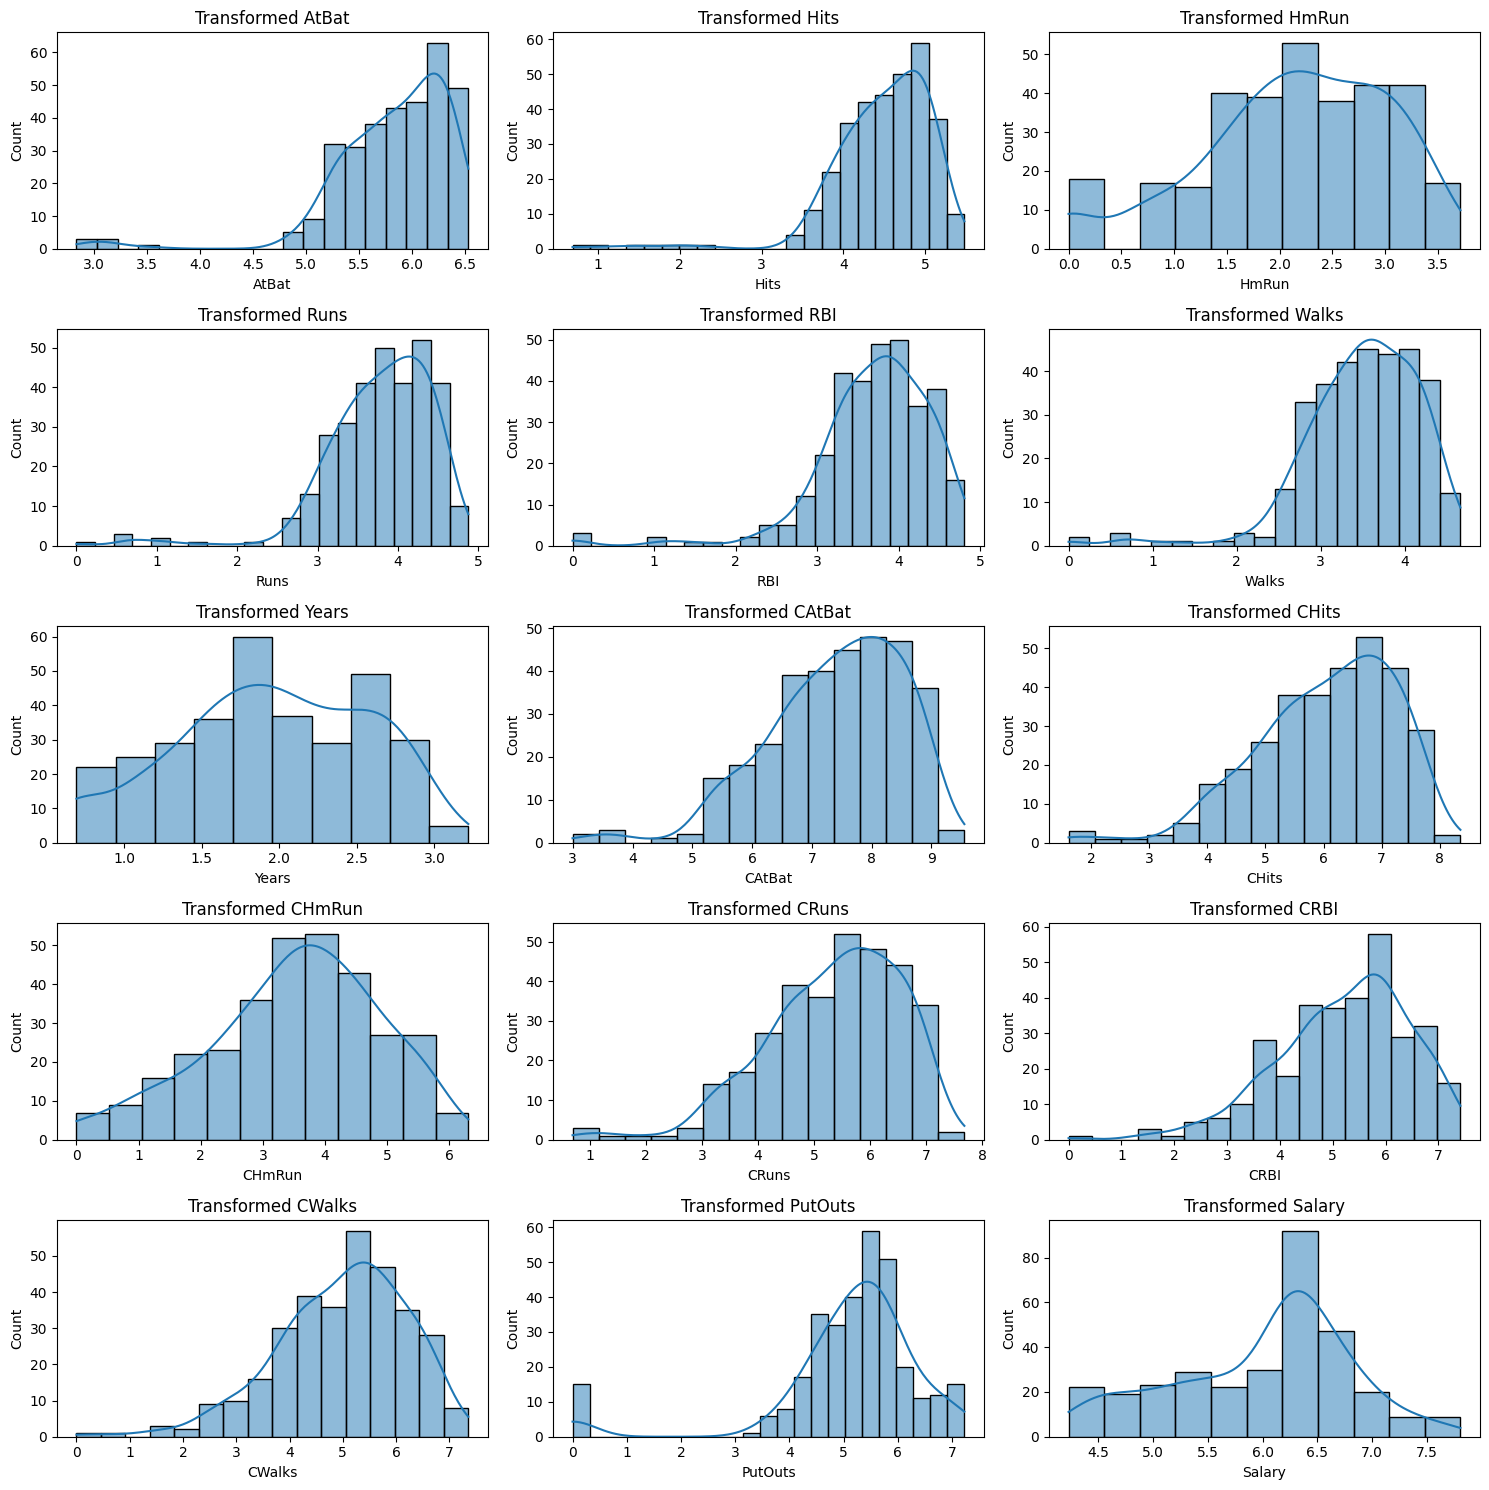

In [ ]:
# Visualize distributions after transformation
num_cols = 3
num_rows = int(np.ceil(len(numerical_cols) / num_cols))
plt.figure(figsize=(15, 15))

for i, col in enumerate(numerical_cols):
    plt.subplot(num_rows, num_cols, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(f"Transformed {col}")

plt.tight_layout()
plt.show()

Skewness has been significantly reduced after transformation.

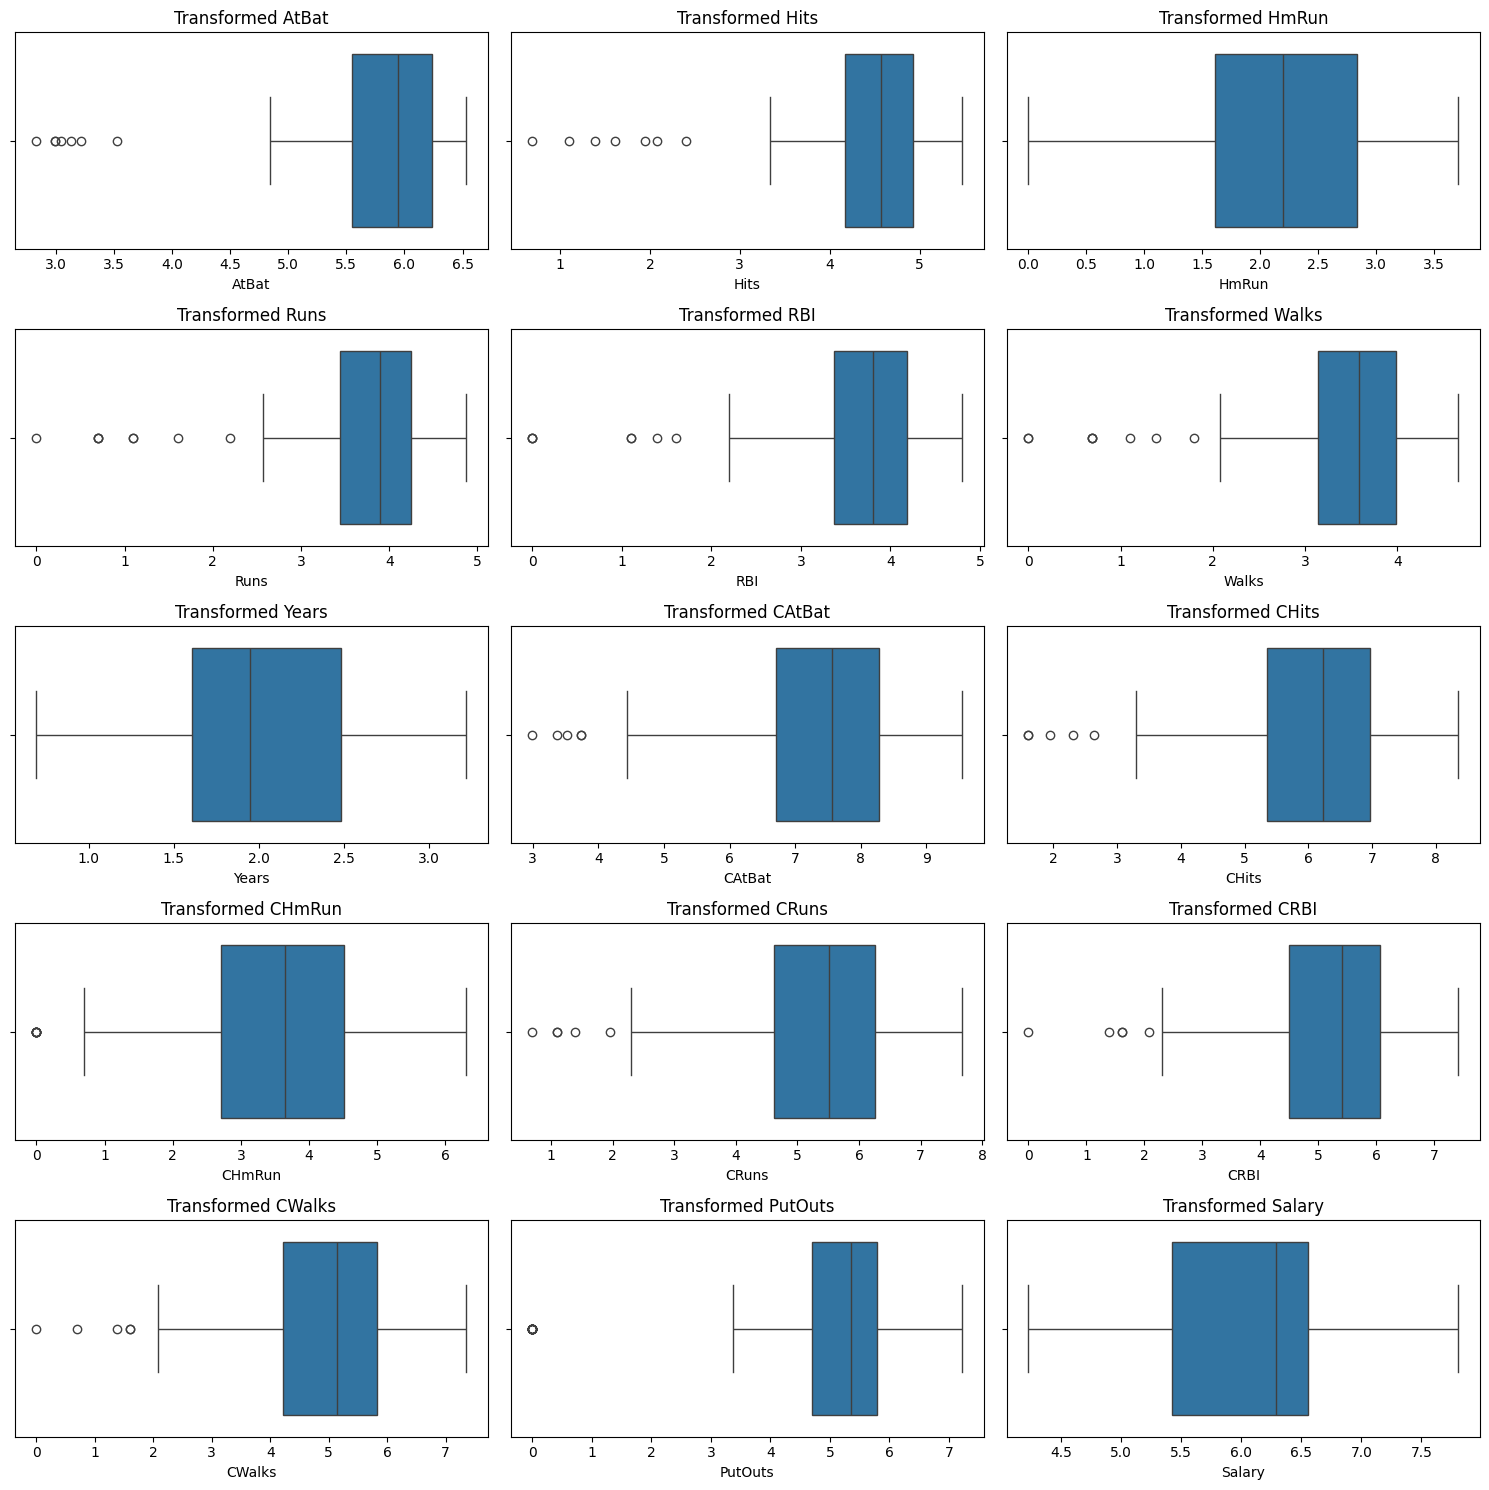

In [ ]:
# Visualize boxplots after transformation
plt.figure(figsize=(15, 15))

for i, col in enumerate(numerical_cols):
    plt.subplot(num_rows, num_cols, i + 1)
    sns.boxplot(x=df[col])
    plt.title(f"Transformed {col}")

plt.tight_layout()
plt.show()

Outliers are still present; apply outlier handling.

In [ ]:
# Handle outliers using IQR method
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
    df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])
    print(f"Outliers handled for {col}.")

Outliers handled for AtBat.
Outliers handled for Hits.
Outliers handled for HmRun.
Outliers handled for Runs.
Outliers handled for RBI.
Outliers handled for Walks.
Outliers handled for Years.
Outliers handled for CAtBat.
Outliers handled for CHits.
Outliers handled for CHmRun.
Outliers handled for CRuns.
Outliers handled for CRBI.
Outliers handled for CWalks.
Outliers handled for PutOuts.
Outliers handled for Salary.


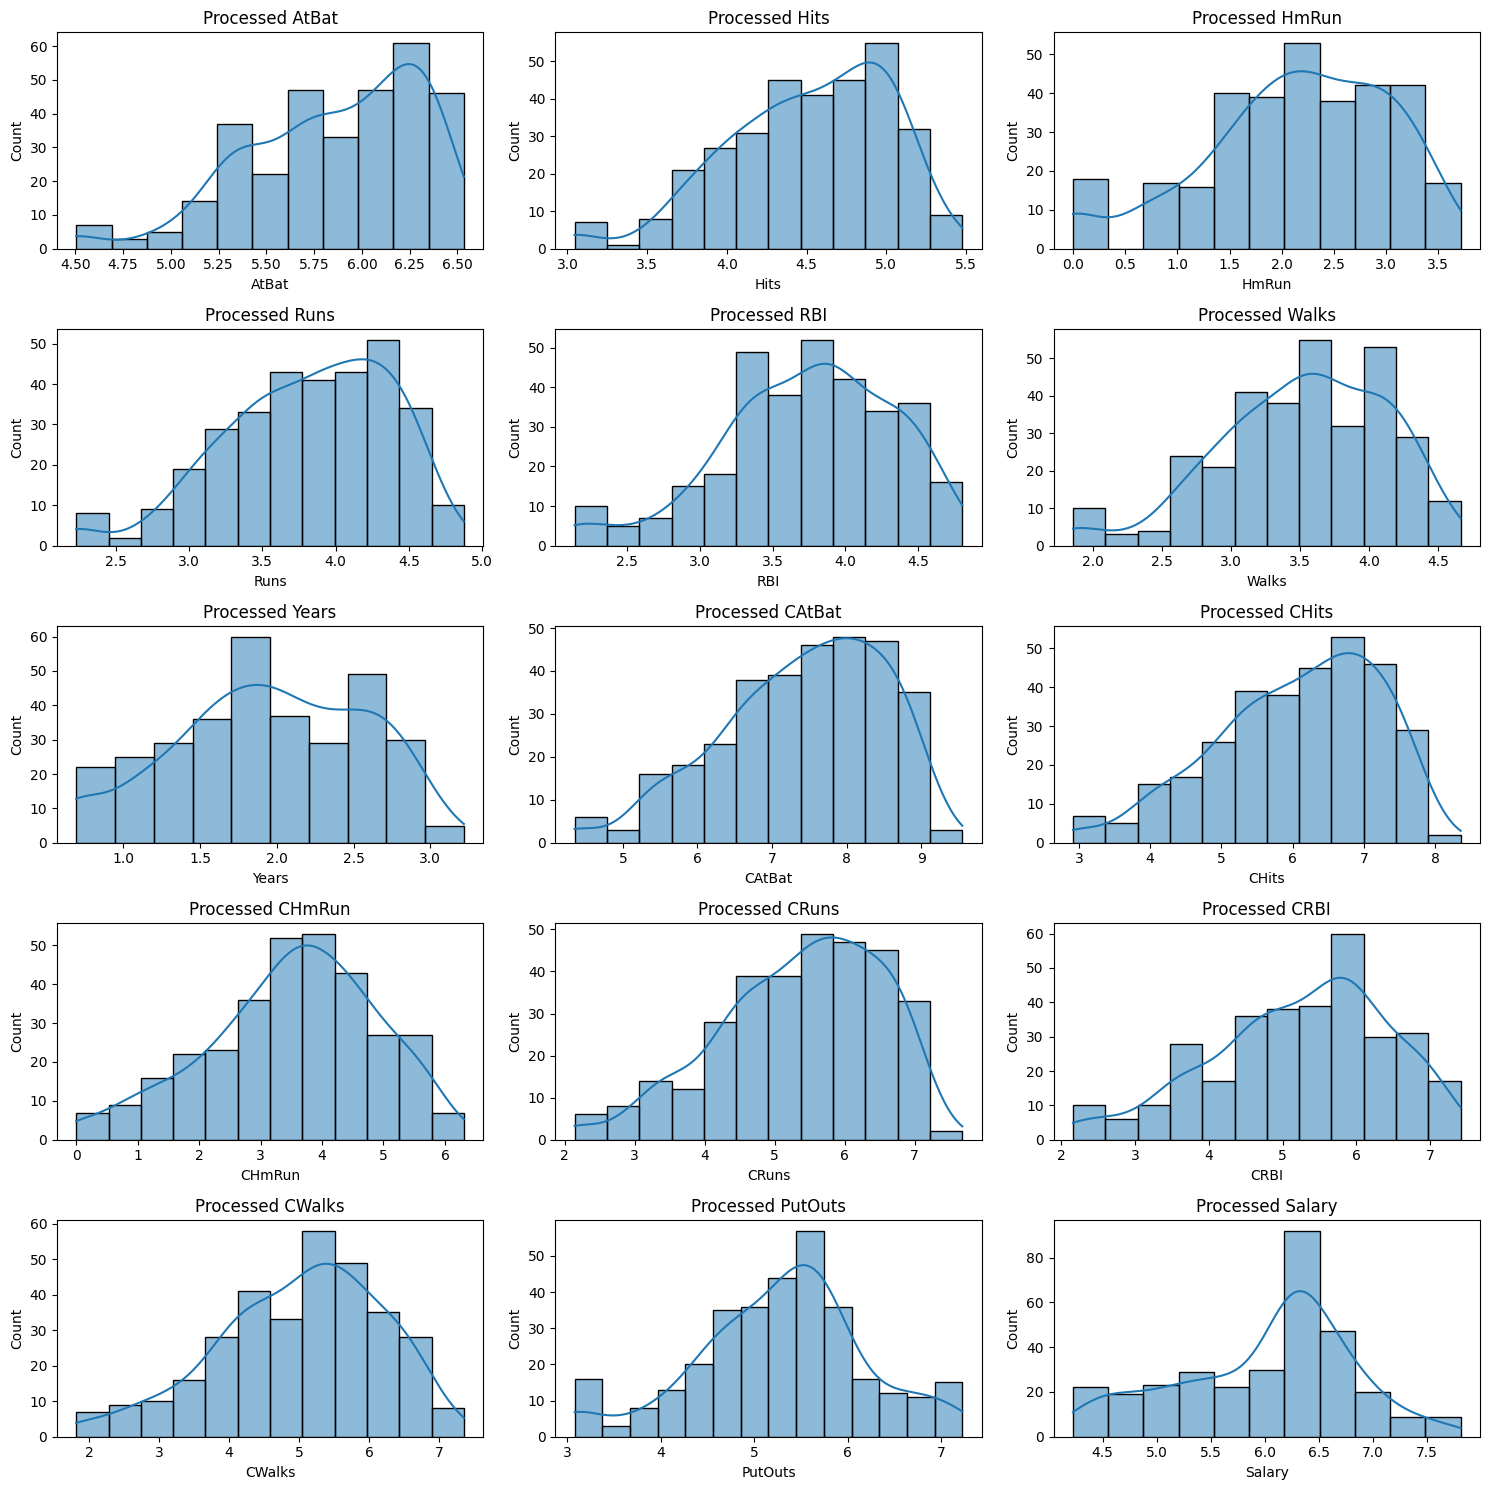

In [ ]:
# Visualize distributions after outlier handling
plt.figure(figsize=(15, 15))

for i, col in enumerate(numerical_cols):
    plt.subplot(num_rows, num_cols, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(f"Processed {col}")

plt.tight_layout()
plt.show()

Skewness has been further reduced.

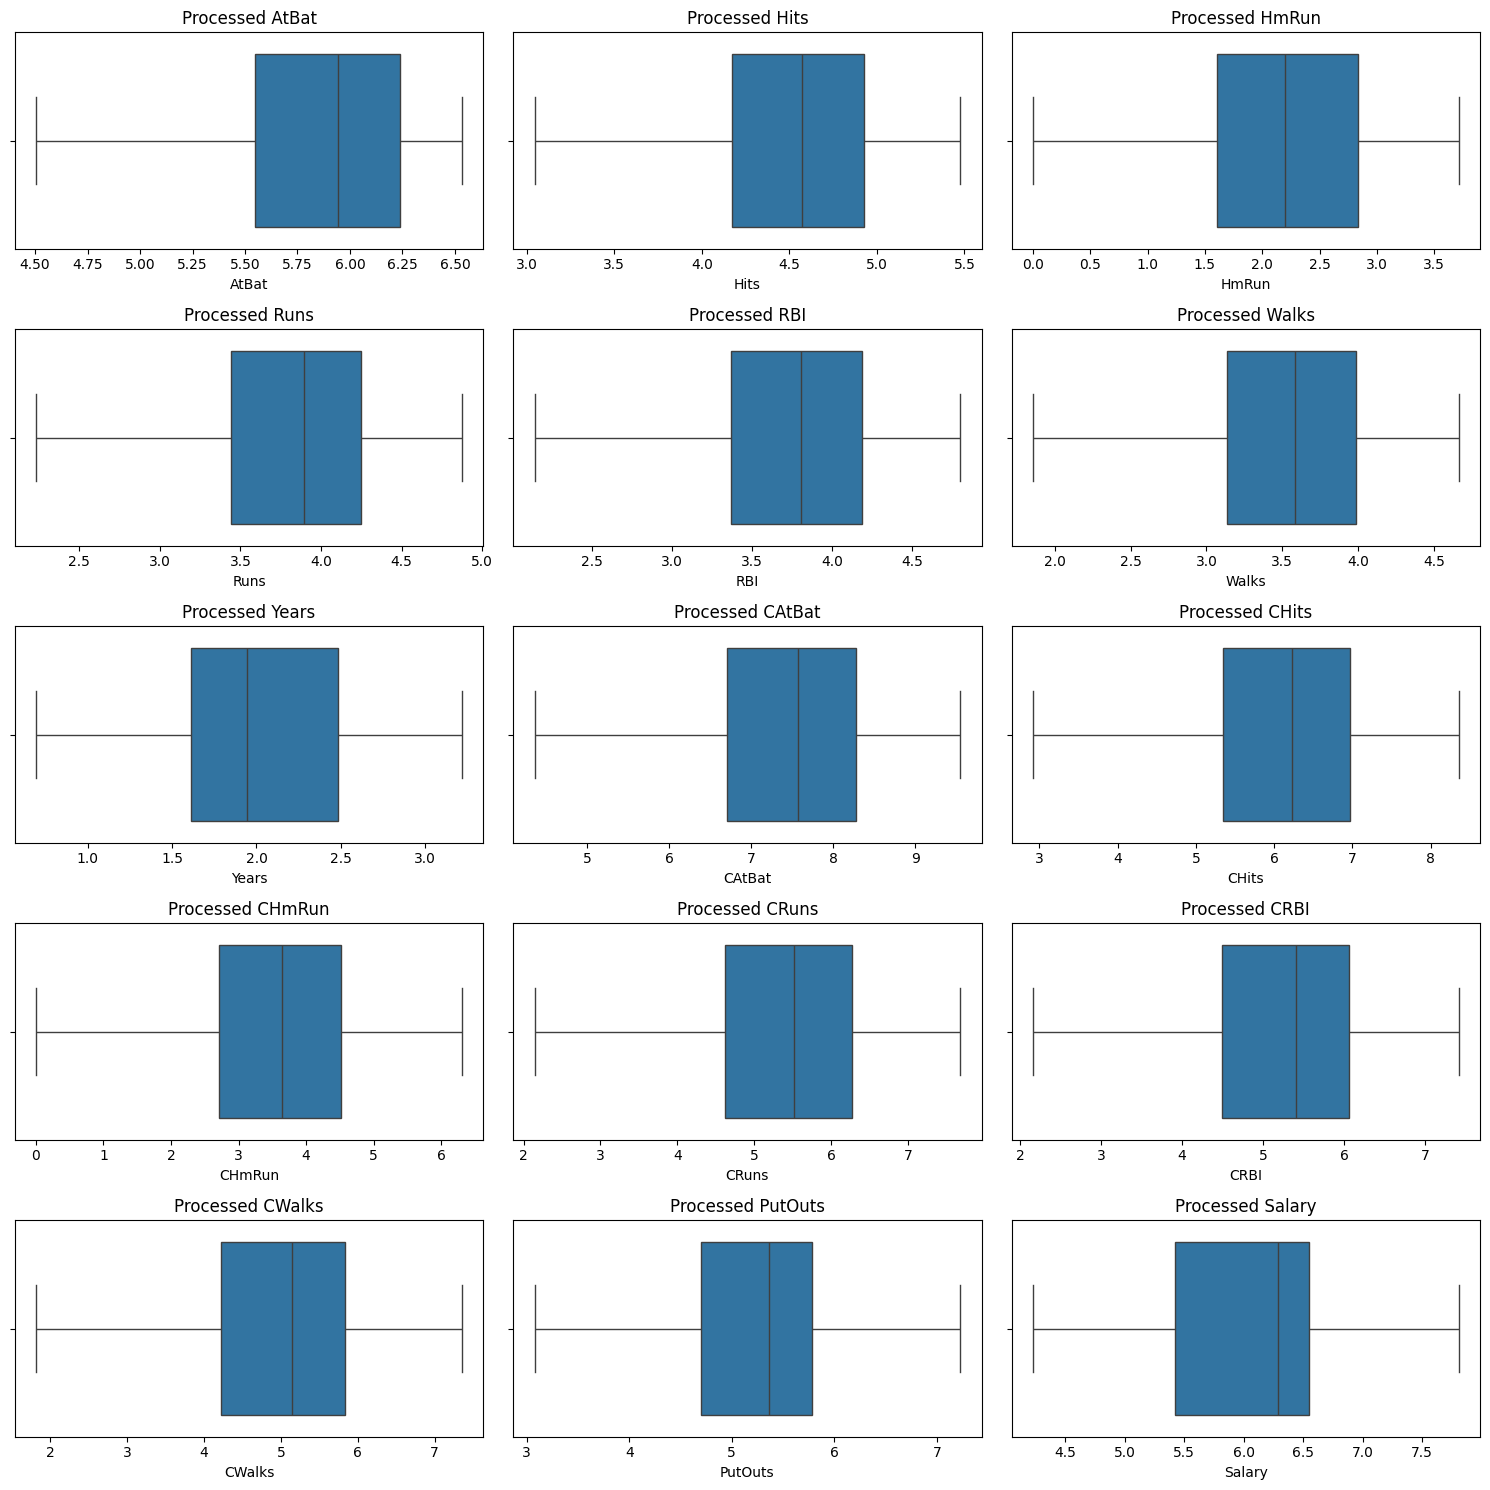

In [ ]:
# Visualize boxplots after outlier handling
plt.figure(figsize=(15, 15))

for i, col in enumerate(numerical_cols):
    plt.subplot(num_rows, num_cols, i + 1)
    sns.boxplot(x=df[col])
    plt.title(f"Processed {col}")

plt.tight_layout()
plt.show()

Outliers have been successfully handled.

In [ ]:
# Split features and target
X = df.drop(columns=["Salary"])
y = df["Salary"]

### Preprocessing Pipeline

In [ ]:
# Create preprocessing pipeline
# Identify numerical and categorical columns
num_cols = X.select_dtypes(exclude="object").columns
cat_cols = X.select_dtypes(include="object").columns

# Pipeline for numerical features
num_pipeline = Pipeline([
    ("scaler", StandardScaler())
])

# Pipeline for categorical features
cat_pipeline = Pipeline([
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

# Combine pipelines
preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
])

In [ ]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Apply preprocessing
X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)

## Model Training and Evaluation

In [ ]:
# Train unpruned Decision Tree model
unpruned_model = DecisionTreeRegressor(random_state=42)
unpruned_model.fit(X_train_preprocessed, y_train)

# Predict and evaluate
y_pred_unpruned = unpruned_model.predict(X_test_preprocessed)

mse_unpruned = mean_squared_error(y_test, y_pred_unpruned)
mae_unpruned = mean_absolute_error(y_test, y_pred_unpruned)
rmse_unpruned = np.sqrt(mse_unpruned)
r2_unpruned = r2_score(y_test, y_pred_unpruned)

print("Unpruned Model Metrics:")
print(f"MSE: {mse_unpruned:.4f}")
print(f"MAE: {mae_unpruned:.4f}")
print(f"RMSE: {rmse_unpruned:.4f}")
print(f"R²: {r2_unpruned:.4f}")

Unpruned Model Metrics:
MSE: 0.4472
MAE: 0.4708
RMSE: 0.6687
R²: 0.0432


The unpruned model performs poorly, likely due to overfitting.

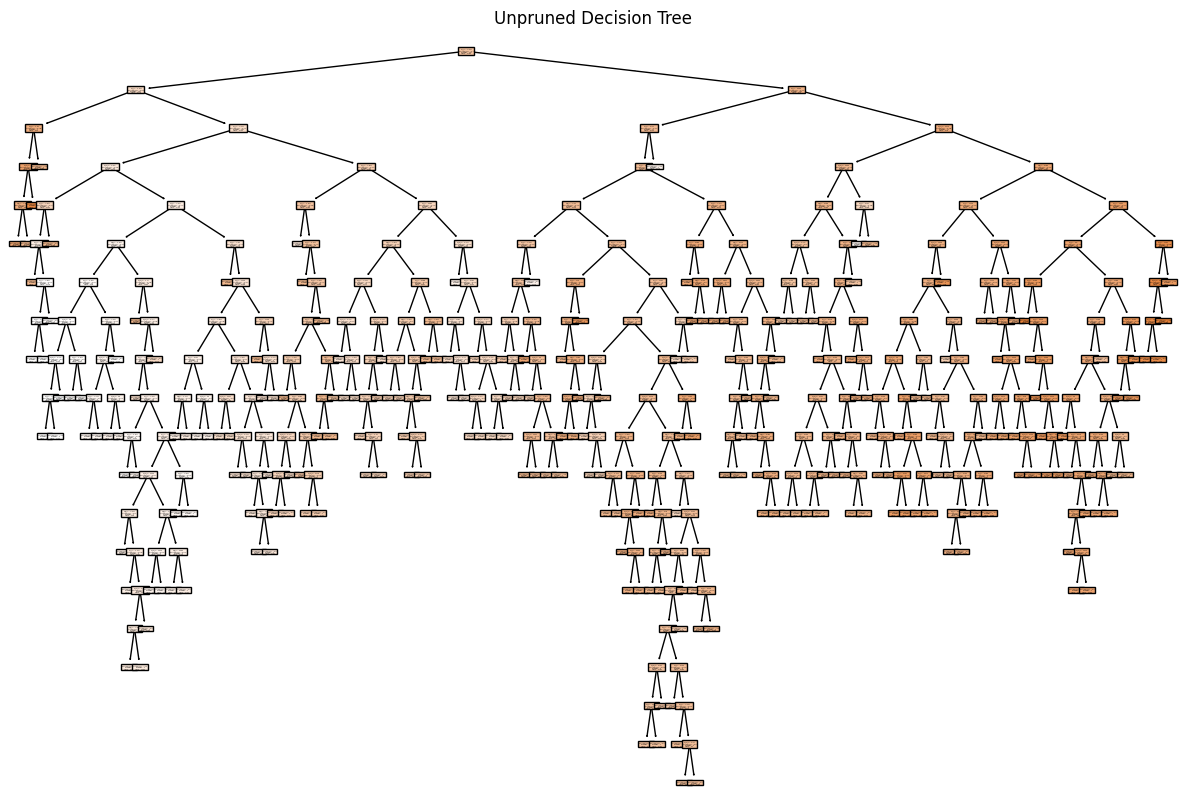

In [ ]:
# Visualize the unpruned tree
plt.figure(figsize=(15, 10))
plot_tree(unpruned_model, filled=True)
plt.title("Unpruned Decision Tree")
plt.show()

The tree is overly complex and hard to interpret.

### Tree Pruning Techniques

There are two main types of tree pruning:
1. **Pre-Pruning**: Stops tree growth early to prevent overfitting.
2. **Post-Pruning**: Removes branches after full growth to improve generalization.

#### Pre-Pruning

In [ ]:
# Train pre-pruned model
model_pre_pruned = DecisionTreeRegressor(max_depth=4, min_samples_leaf=10, random_state=42)
model_pre_pruned.fit(X_train_preprocessed, y_train)

# Predict and evaluate
y_pred_pre_pruned = model_pre_pruned.predict(X_test_preprocessed)

r2_pre_pruned = r2_score(y_test, y_pred_pre_pruned)

print("Pre-Pruned Model Metrics:")
print(f"MSE: {mean_squared_error(y_test, y_pred_pre_pruned):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_pre_pruned):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_pre_pruned)):.4f}")
print(f"R²: {r2_pre_pruned:.4f}")

Pre-Pruned Model Metrics:
MSE: 0.2028
MAE: 0.3629
RMSE: 0.4504
R²: 0.5660


Pre-pruning significantly improves performance and interpretability.

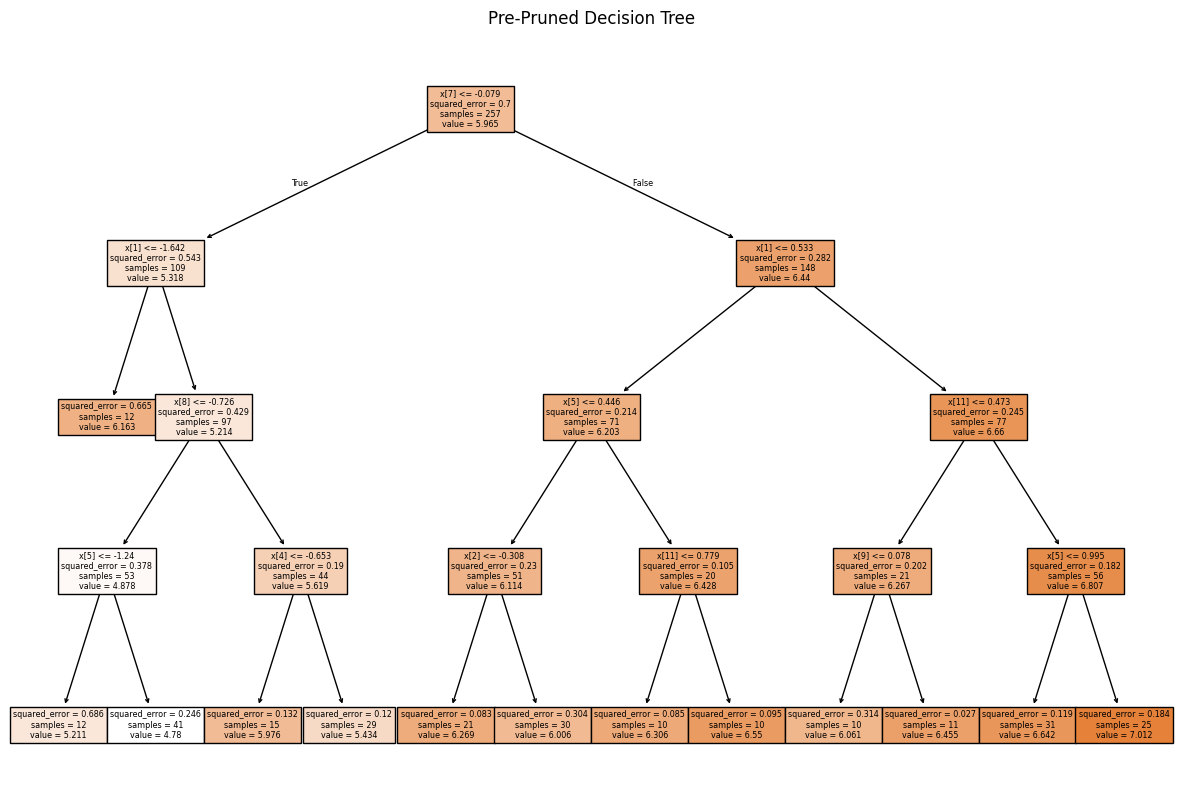

In [ ]:
# Visualize the pre-pruned tree
plt.figure(figsize=(15, 10))
plot_tree(model_pre_pruned, filled=True)
plt.title("Pre-Pruned Decision Tree")
plt.show()

The tree is now more interpretable.

#### Post-Pruning (Cost-Complexity Pruning)

In [ ]:
# Get cost-complexity pruning path
path = unpruned_model.cost_complexity_pruning_path(X_train_preprocessed, y_train)
ccp_alphas = path.ccp_alphas

Train models with different alpha values for pruning.

In [ ]:
# Train models for each alpha
models = []
for alpha in ccp_alphas:
    dt = DecisionTreeRegressor(random_state=42, ccp_alpha=alpha)
    dt.fit(X_train_preprocessed, y_train)
    models.append(dt)

Collect training and testing scores.

In [ ]:
# Calculate scores
train_scores = [model.score(X_train_preprocessed, y_train) for model in models]
test_scores = [model.score(X_test_preprocessed, y_test) for model in models]

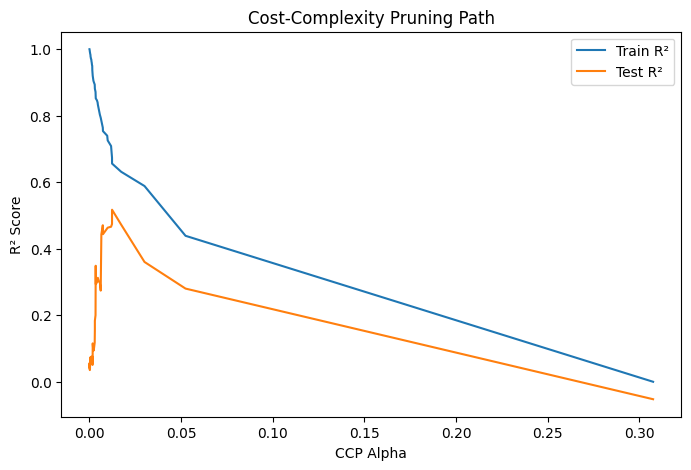

In [ ]:
# Plot scores vs alpha
plt.figure(figsize=(8, 5))
plt.plot(ccp_alphas, train_scores, label='Train R²')
plt.plot(ccp_alphas, test_scores, label='Test R²')
plt.xlabel("CCP Alpha")
plt.ylabel("R² Score")
plt.title("Cost-Complexity Pruning Path")
plt.legend()
plt.show()

In [ ]:
# Select best alpha and train final post-pruned model
best_alpha = ccp_alphas[np.argmax(test_scores)]

dt_post_pruned = DecisionTreeRegressor(random_state=42, ccp_alpha=best_alpha)
dt_post_pruned.fit(X_train_preprocessed, y_train)

y_pred_post = dt_post_pruned.predict(X_test_preprocessed)
r2_post_pruned = r2_score(y_test, y_pred_post)

print("Post-Pruned Model Metrics:")
print(f"Best Alpha: {best_alpha:.6f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_post)):.4f}")
print(f"R²: {r2_post_pruned:.4f}")

Post-Pruned Model Metrics:
Best Alpha: 0.012323
RMSE: 0.4749
R²: 0.5174


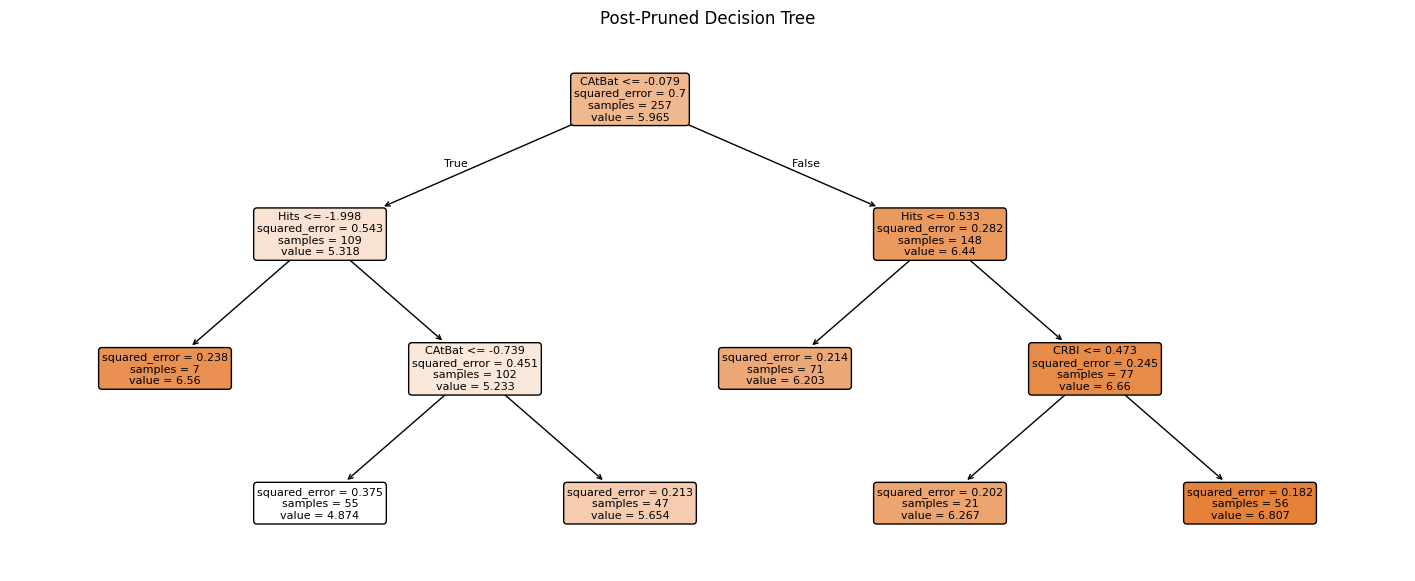

In [ ]:
# Visualize the post-pruned tree
plt.figure(figsize=(18, 7))
plot_tree(
    dt_post_pruned,
    feature_names=list(X.columns),
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("Post-Pruned Decision Tree")
plt.show()

**Key Observations:**

- The unpruned model was overly complex and performed poorly due to overfitting.
- Pre-pruning improved performance and interpretability by limiting tree depth and minimum samples.
- Post-pruning also enhanced results by removing unnecessary branches.
- In this case, pre-pruning yielded better results than post-pruning.

### Model Comparison and Selection

In [ ]:
# Compare model performances
model_metrics = {
    'Model': ['Unpruned', 'Pre-Pruned', 'Post-Pruned'],
    'MSE': [
        mean_squared_error(y_test, y_pred_unpruned),
        mean_squared_error(y_test, y_pred_pre_pruned),
        mean_squared_error(y_test, y_pred_post)
    ],
    'MAE': [
        mean_absolute_error(y_test, y_pred_unpruned),
        mean_absolute_error(y_test, y_pred_pre_pruned),
        mean_absolute_error(y_test, y_pred_post)
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test, y_pred_unpruned)),
        np.sqrt(mean_squared_error(y_test, y_pred_pre_pruned)),
        np.sqrt(mean_squared_error(y_test, y_pred_post))
    ],
    'R²': [r2_unpruned, r2_pre_pruned, r2_post_pruned]
}

metrics_df = pd.DataFrame(model_metrics)
print("Model Performance Comparison:")
display(metrics_df)

# Select the best model based on R²
best_model_idx = metrics_df['R²'].idxmax()
best_model_name = metrics_df.loc[best_model_idx, 'Model']
best_r2 = metrics_df.loc[best_model_idx, 'R²']

print(f"\nBest Model: {best_model_name} with R² = {best_r2:.4f}")

# Save the best model
if best_model_name == 'Pre-Pruned':
    best_model = model_pre_pruned
elif best_model_name == 'Post-Pruned':
    best_model = dt_post_pruned
else:
    best_model = unpruned_model

joblib.dump(best_model, 'best_decision_tree_model.pkl')
joblib.dump(preprocessor, 'preprocessor.pkl')
print(f"\nBest model ({best_model_name}) and preprocessor saved successfully.")

Model Performance Comparison:


,Model,MSE,MAE,RMSE,R²
0,Unpruned,0.447183,0.470845,0.668718,0.043151
1,Pre-Pruned,0.202834,0.362890,0.450371,0.565991
2,Post-Pruned,0.225565,0.379840,0.474937,0.517352



Best Model: Pre-Pruned with R² = 0.5660

Best model (Pre-Pruned) and preprocessor saved successfully.


## Conclusion

Tree pruning is crucial for Decision Tree models as it reduces overfitting, improves accuracy, and enhances interpretability. Both pre-pruning and post-pruning techniques help create more reliable and generalizable models for predicting basketball player salaries.